In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats


In [20]:
df = sns.load_dataset('titanic')
print(df.info())
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
survived         0
pclass           0
sex              0
age            17

In [21]:
cat_cols = ['sex', 'survived']
df_cat = df[cat_cols].copy()

print(df_cat.nunique())
print(df_cat.describe(include='object'))

sex         2
survived    2
dtype: int64
         sex
count    891
unique     2
top     male
freq     577


In [22]:
ct = pd.crosstab(df_cat['sex'], df_cat['survived'])
ct_pct = pd.crosstab(df_cat['sex'], df_cat['survived'], normalize='index') * 100
print(ct)
print(ct_pct.round(1))

survived    0    1
sex               
female     81  233
male      468  109
survived     0     1
sex                 
female    25.8  74.2
male      81.1  18.9


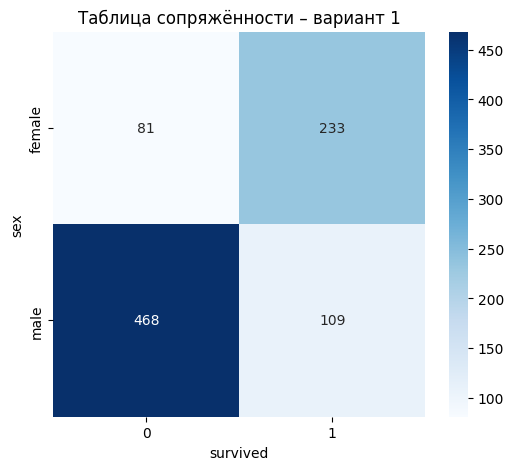

In [23]:

plt.figure(figsize=(6, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Таблица сопряжённости – вариант 1')
plt.savefig('heatmap_ct.png', dpi=150, bbox_inches='tight')
plt.show()

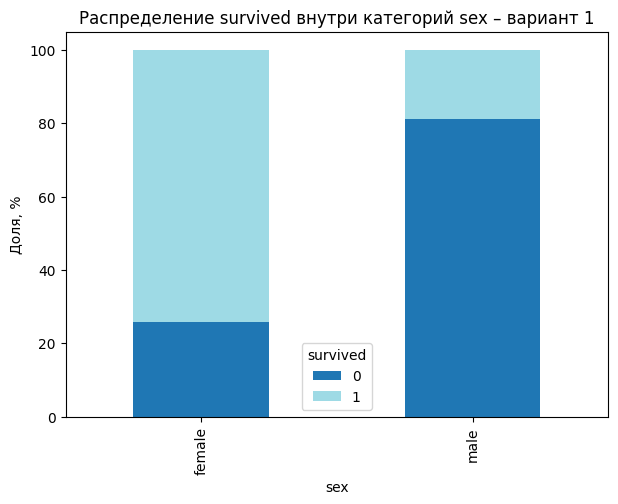

In [24]:
ct_pct.plot(kind='bar', stacked=True, figsize=(7, 5), colormap='tab20')
plt.ylabel('Доля, %')
plt.title('Распределение survived внутри категорий sex – вариант 1')
plt.savefig('stacked_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
chi2, p_value, dof, expected = stats.chi2_contingency(ct)
n = ct.values.sum()
r, c = ct.shape

cramers_v = np.sqrt((chi2 / n) / (min(r, c) - 1))
tschuprow_t = np.sqrt((chi2 / n) / np.sqrt((r - 1) * (c - 1)))

print(f'chi2 = {chi2:.3f}, dof = {dof}, p-value = {p_value:.4f}')
print(f'V Крамера = {cramers_v:.3f}')
print(f'T Чупрова = {tschuprow_t:.3f}')


chi2 = 260.717, dof = 1, p-value = 0.0000
V Крамера = 0.541
T Чупрова = 0.541


In [26]:
alpha = 0.05
if p_value < alpha:
    print(f'H0 отклонена (p={p_value:.4f} < {alpha}): признаки статистически связаны')
else:
    print(f'H0 не отклонена (p={p_value:.4f} >= {alpha}): связь не доказана')

print('Ожидаемые частоты:'); print(np.round(expected, 1))
print('Доля ячеек с ожидаемой частотой < 5:', (expected < 5).mean())


H0 отклонена (p=0.0000 < 0.05): признаки статистически связаны
Ожидаемые частоты:
[[193.5 120.5]
 [355.5 221.5]]
Доля ячеек с ожидаемой частотой < 5: 0.0
